In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

# Load datasets
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [3]:
# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort NAV
nav = nav.sort_values(["amfi_code", "date"])

In [4]:
# Daily Return = NAV_t / NAV_t-1 - 1

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


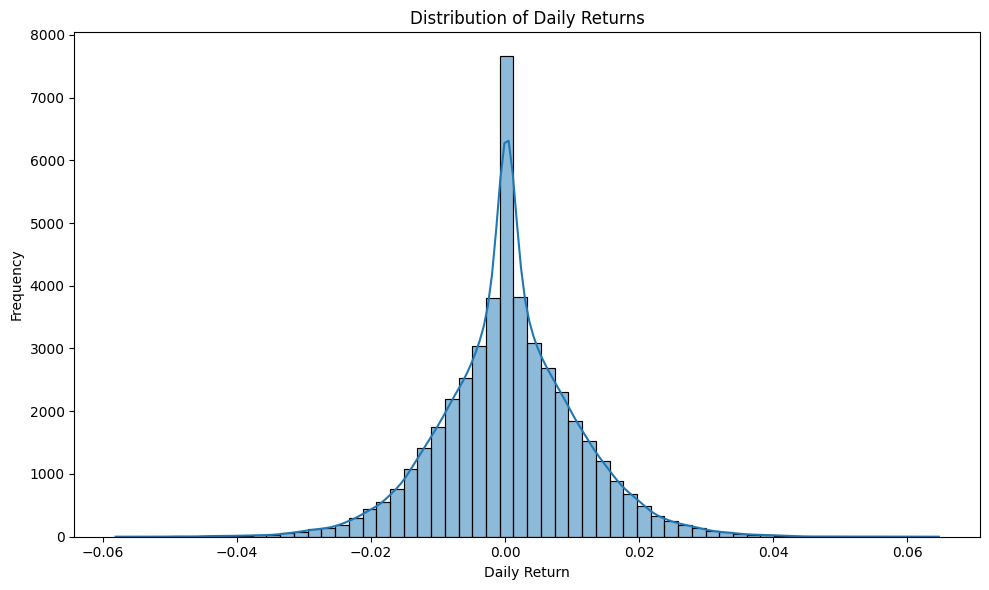

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
def calculate_cagr(group, years):
    """
    Calculate CAGR for a given fund and time period.
    """
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period_data = group[group["date"] >= start_date]

    if len(period_data) < 2:
        return np.nan

    start_nav = period_data.iloc[0]["nav"]
    end_nav = period_data.iloc[-1]["nav"]

    if start_nav <= 0:
        return np.nan

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr * 100

In [7]:
cagr_table = pd.DataFrame()

cagr_table["amfi_code"] = nav["amfi_code"].unique()

cagr_table["CAGR_1Y"] = [
    calculate_cagr(nav[nav["amfi_code"] == code], 1)
    for code in cagr_table["amfi_code"]
]

cagr_table["CAGR_3Y"] = [
    calculate_cagr(nav[nav["amfi_code"] == code], 3)
    for code in cagr_table["amfi_code"]
]

cagr_table["CAGR_5Y"] = [
    calculate_cagr(nav[nav["amfi_code"] == code], 5)
    for code in cagr_table["amfi_code"]
]

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [8]:
cagr_table = cagr_table.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_table = cagr_table[
    ["amfi_code", "scheme_name", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]
]

cagr_table.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [9]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR table saved successfully!")

CAGR table saved successfully!


In [1]:
# Annual risk-free rate
rf_annual = 0.065

# Daily risk-free rate
rf_daily = rf_annual / 252

In [4]:
# Make this cell runnable independently (even if previous cells were not executed).
if "pd" not in globals():
    import pandas as pd
if "np" not in globals():
    import numpy as np

if "nav" not in globals():
    nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
    nav["date"] = pd.to_datetime(nav["date"])
    nav = nav.sort_values(["amfi_code", "date"])
    nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

if "rf_daily" not in globals():
    rf_annual = 0.065
    rf_daily = rf_annual / 252

sharpe_list = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    avg_return = returns.mean()
    std_return = returns.std()

    # Skip funds with zero/undefined volatility to avoid invalid Sharpe values.
    if pd.isna(std_return) or std_return == 0:
        continue

    sharpe = ((avg_return - rf_daily) / std_return) * np.sqrt(252)

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [6]:
if "pd" not in globals():
    import pandas as pd

if "fund_master" not in globals():
    fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

if "sharpe_df" not in globals():
    raise NameError("sharpe_df is not defined. Run the Sharpe calculation cell first.")

sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
 )

sharpe_df.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [7]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df["Sharpe_Rank"] = range(
    1,
    len(sharpe_df) + 1
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name,Sharpe_Rank
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,6
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


In [8]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [9]:
print(sharpe_df.shape)

(40, 4)


In [10]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Only negative returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        continue

    avg_return = returns.mean()
    downside_std = downside_returns.std()

    sortino = ((avg_return - rf_daily) / downside_std) * np.sqrt(252)

    sortino_list.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df.head()

,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [12]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df["Sortino_Rank"] = range(
    1,
    len(sortino_df) + 1
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name,Sortino_Rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


In [13]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [15]:
if "pd" not in globals():
    import pandas as pd

if "benchmark" not in globals():
    benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

if "date" in benchmark.columns and not pd.api.types.is_datetime64_any_dtype(benchmark["date"]):
    benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")

# Keep only Nifty 100 benchmark
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [16]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [17]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
alpha_beta = []

benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].dropna()

In [21]:
if "pd" not in globals():
    import pandas as pd
if "linregress" not in globals():
    from scipy.stats import linregress

if "nav" not in globals():
    nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
    nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
    nav = nav.sort_values(["amfi_code", "date"])
    nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

if "benchmark_returns" not in globals():
    if "benchmark" not in globals():
        benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")
    if "date" in benchmark.columns and not pd.api.types.is_datetime64_any_dtype(benchmark["date"]):
        benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
    nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
    nifty100 = nifty100.sort_values("date")
    nifty100["benchmark_return"] = nifty100["close_value"].pct_change()
    benchmark_returns = nifty100[["date", "benchmark_return"]].dropna()

alpha_beta = []

for code, group in nav.groupby("amfi_code"):
    fund_returns = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_Squared": r_value ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [22]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared,scheme_name
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [23]:
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,R_Squared,scheme_name
21,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,1.206652e-05,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,4.625437e-04,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,3.357978e-06,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,1.936879e-03,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,8.869789e-04,SBI Bluechip Fund - Regular Plan - Growth


In [24]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully!")

alpha_beta.csv created successfully!


In [25]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [26]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    # Worst drawdown
    worst_idx = group["drawdown"].idxmin()
    worst_row = group.loc[worst_idx]

    drawdown_list.append({
        "amfi_code": code,
        "Max_Drawdown": worst_row["drawdown"] * 100,
        "Worst_Date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_list)

drawdown_df.head()

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-24.734441,2022-09-15
1,100025,-4.308264,2023-07-28
2,100033,-16.217209,2022-05-12
3,101206,-11.291596,2023-07-05
4,101207,-35.446916,2026-05-11


In [27]:
drawdown_df = drawdown_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

drawdown_df.head()

,amfi_code,Max_Drawdown,Worst_Date,scheme_name
0,100016,-24.734441,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-4.308264,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-16.217209,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-11.291596,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-35.446916,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [28]:
drawdown_df = drawdown_df.sort_values(
    by="Max_Drawdown",
    ascending=False
)

drawdown_df["Drawdown_Rank"] = range(
    1,
    len(drawdown_df) + 1
)

drawdown_df.head(10)

,amfi_code,Max_Drawdown,Worst_Date,scheme_name,Drawdown_Rank
27,120507,-0.097731,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,1
31,120844,-0.116293,2024-04-30,Kotak Liquid Fund - Regular - Growth,2
5,101208,-0.162250,2023-09-12,ABSL Liquid Fund - Regular - Growth,3
1,100025,-4.308264,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,4
18,119120,-4.328729,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,5
13,118636,-8.316362,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...,6
6,102885,-10.859862,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,7
34,148567,-11.265729,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,8
3,101206,-11.291596,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,9
12,118635,-11.650625,2022-06-09,Nippon India ETF Nifty 50 BeES,10


In [29]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown file saved successfully!")

Maximum Drawdown file saved successfully!


In [31]:
if "pd" not in globals():
    import pandas as pd

if "performance" not in globals():
    performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

required_cols = ["amfi_code", "return_3yr_pct", "expense_ratio_pct"]
missing_cols = [col for col in required_cols if col not in performance.columns]
if missing_cols:
    raise KeyError(f"Missing columns in performance data: {missing_cols}")

return_rank = performance[required_cols].copy()

return_rank["Return_Rank"] = (
    return_rank["return_3yr_pct"]
    .rank(ascending=False, method="dense")
)

return_rank.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,Return_Rank
0,119551,12.36,1.54,26.0
1,119552,11.30,0.66,34.0
2,119598,23.39,1.43,1.0
3,119599,23.14,0.72,2.0
4,119120,6.07,0.77,38.0


In [32]:
return_rank["Expense_Rank"] = (
    return_rank["expense_ratio_pct"]
    .rank(ascending=True, method="dense")
)

return_rank.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank
0,119551,12.36,1.54,26.0,24.0
1,119552,11.30,0.66,34.0,4.0
2,119598,23.39,1.43,1.0,18.0
3,119599,23.14,0.72,2.0,5.0
4,119120,6.07,0.77,38.0,8.0


In [33]:
alpha_rank = alpha_beta_df[
    ["amfi_code", "Alpha"]
].copy()

alpha_rank["Alpha_Rank"] = (
    alpha_rank["Alpha"]
    .rank(ascending=False, method="dense")
)

In [34]:
scorecard = return_rank.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_rank[["amfi_code", "Alpha_Rank"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank
0,119551,12.36,1.54,26.0,24.0,4,10.0,17
1,119552,11.30,0.66,34.0,4.0,12,15.0,11
2,119598,23.39,1.43,1.0,18.0,14,1.0,36
3,119599,23.14,0.72,2.0,5.0,32,36.0,40
4,119120,6.07,0.77,38.0,8.0,37,34.0,5


In [35]:
max_rank = scorecard[
    [
        "Return_Rank",
        "Sharpe_Rank",
        "Alpha_Rank",
        "Expense_Rank",
        "Drawdown_Rank"
    ]
].max().max()

scorecard["Fund_Score"] = (

    (max_rank - scorecard["Return_Rank"] + 1)
    * 30 / max_rank

    +

    (max_rank - scorecard["Sharpe_Rank"] + 1)
    * 25 / max_rank

    +

    (max_rank - scorecard["Alpha_Rank"] + 1)
    * 20 / max_rank

    +

    (max_rank - scorecard["Expense_Rank"] + 1)
    * 15 / max_rank

    +

    (max_rank - scorecard["Drawdown_Rank"] + 1)
    * 10 / max_rank

)

In [36]:
scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score,scheme_name
12,120505,18.08,1.36,8.0,14.0,5,3.0,25,80.375,ICICI Pru Midcap Fund - Regular - Growth
22,120843,15.65,1.45,11.0,19.0,2,5.0,13,80.125,Kotak Flexicap Fund - Regular - Growth
7,100033,16.58,1.38,10.0,15.0,7,6.0,20,77.000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,119598,23.39,1.43,1.0,18.0,14,1.0,36,76.750,SBI Small Cap Fund - Regular Plan - Growth
34,148567,14.81,1.46,17.0,20.0,1,7.0,8,76.125,Mirae Asset Large Cap Fund - Regular - Growth
39,149324,20.08,1.52,6.0,22.0,13,2.0,37,71.375,DSP Small Cap Fund - Regular - Growth
38,149323,17.16,1.61,9.0,30.0,6,8.0,22,71.250,DSP Midcap Fund - Regular - Growth
11,120504,14.41,0.80,20.0,11.0,10,13.0,12,67.625,ICICI Pru Bluechip Fund - Direct - Growth
26,119094,15.18,1.38,15.0,15.0,11,9.0,28,67.250,Axis Midcap Fund - Regular - Growth
36,148569,13.58,1.60,23.0,29.0,3,4.0,21,65.250,Mirae Asset Tax Saver Fund - Regular - Growth


In [37]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard created successfully!")

Fund Scorecard created successfully!


In [38]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 120843, 100033, 119598, 148567]

In [39]:
top5_nav = nav[nav["amfi_code"].isin(top5)].copy()

top5_nav = top5_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [40]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [41]:
benchmark_compare = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare["normalized_value"] = (
    benchmark_compare.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [43]:
if "px" not in globals():
    import plotly.express as px

if "top5_nav" not in globals():
    raise NameError("top5_nav is not defined. Run the benchmark comparison preparation cells first.")

fig = px.line(
    top5_nav,
    x="date",
    y="normalized_nav",
    color="scheme_name",
    title="Top 5 Funds vs Benchmarks (Normalized Performance)"
 )

fig.show()

In [44]:
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_compare[
        benchmark_compare["index_name"] == index
    ]

    fig.add_scatter(
        x=temp["date"],
        y=temp["normalized_value"],
        mode="lines",
        name=index,
        line=dict(width=4)
    )

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

In [45]:
fig.write_image(
    "../reports/charts/benchmark_comparison.png"
)

In [46]:
benchmark_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "close_value"]].copy()

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

benchmark_returns = benchmark_returns.dropna()

In [47]:
tracking_error = []

for code, group in nav.groupby("amfi_code"):

    temp = group[
        ["date", "daily_return"]
    ].dropna()

    merged = pd.merge(
        temp,
        benchmark_returns[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    if len(merged) < 30:
        continue

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

tracking_df = pd.DataFrame(tracking_error)

In [48]:
tracking_df = tracking_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

tracking_df.head()

,amfi_code,Tracking_Error,scheme_name
0,100016,0.199284,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.134535,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.192706,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.292117,ABSL Small Cap Fund - Regular - Growth


In [49]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error file created successfully!")

Tracking Error file created successfully!
